In [1]:
from __future__ import division, print_function
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table, vstack, hstack
import fitsio
import sys, os, glob, time, warnings, gc
# import healpy as hp

from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import LogNorm

sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/Users/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
downsample_factor = 16
field = 'south'

In [4]:
cat_columns = ['TYPE', 'RA', 'DEC', 'EBV', 
          'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'FLUX_IVAR_W1', 'FLUX_IVAR_W2', 
          'NOBS_G', 'NOBS_R', 'NOBS_Z', 'NOBS_W1', 'NOBS_W2', 
          'FIBERFLUX_G', 'FIBERFLUX_R', 'FIBERFLUX_Z', 
          'MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2', 
          'MASKBITS',
          'z_phot_mean', 'z_phot_median', 'z_phot_std', 'z_phot_l68', 'z_phot_u68', 'z_phot_l95', 'z_phot_u95',
          'z_spec', 'survey', 'training']

cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_lrg_selection/dr9m-sep26-2020/lrg_extended_20201016_ds_{}.fits'.format(field), columns=cat_columns))
print(len(cat))
if field=='south':
    mask = cat['DEC']<32.375
elif field=='north':
    mask = (cat['DEC']>32.375) & (cat['RA']>70) & (cat['RA']<310)
else:
    raise ValueError('invalid field')
mask &= (cat['NOBS_G']>=2) & (cat['NOBS_R']>=2) & (cat['NOBS_Z']>=2)
mask &= cat['DEC']>-30
cat = cat[mask]
print(len(cat))

randoms_columns = ['RA', 'DEC', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'MASKBITS']
randoms_full_size = 63283970
randoms_load_size = int(1e7)
randoms_density = 5000./randoms_full_size*randoms_load_size
randoms = fitsio.read('/Users/rongpu/Documents/Data/desi_lrg_selection/dr9m-sep26-2020/randoms-1-0.fits', 
                      columns=randoms_columns, rows=np.arange(randoms_load_size))
print(len(randoms))
if field=='south':
    mask = randoms['DEC']<32.375
elif field=='north':
    mask = (randoms['DEC']>32.375) & (randoms['RA']>70) & (randoms['RA']<310)
else:
    raise ValueError('invalid field')
mask &= (randoms['NOBS_G']>=2) & (randoms['NOBS_R']>=2) & (randoms['NOBS_Z']>=2)
mask &= randoms['DEC']>-30
randoms = randoms[mask]
print(len(randoms))

8807989
8535911
10000000
5026626


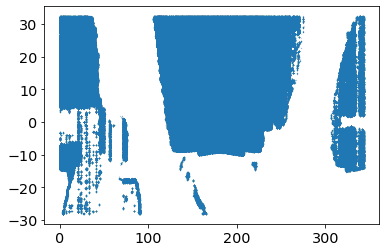

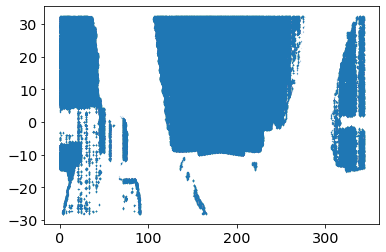

In [5]:
plt.plot(cat['RA'], cat['DEC'], '.', ms=0.1)
plt.show()

plt.plot(randoms['RA'], randoms['DEC'], '.', ms=0.1)
plt.show()

__Clean up the data__

In [6]:
maskbits = [1, 5, 6, 7, 8, 9, 11, 12, 13]

mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print('{:} ({:.1f}%) objects removed by maskbits'.format(np.sum(~mask_clean), np.sum(~mask_clean)/len(mask_clean)*100))
cat = cat[mask_clean]
print(len(cat))

mask_clean = np.ones(len(randoms), dtype=bool)
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:} ({:.1f}%) randoms removed by maskbits'.format(np.sum(~mask_clean), np.sum(~mask_clean)/len(mask_clean)*100))
randoms = randoms[mask_clean]
print(len(randoms))

502007 (5.9%) objects removed by maskbits
8033904
276147 (5.5%) randoms removed by maskbits
4750479


__Basic quality cuts__

In [7]:
mask = (cat['FLUX_R']>0) & (cat['FLUX_IVAR_R']>0)
mask &= (cat['FLUX_Z']>0) & (cat['FLUX_IVAR_Z']>0)
mask &= (cat['FLUX_W1']>0) & (cat['FLUX_IVAR_W1']>0)
print(np.sum(~mask)/len(mask), np.sum(~mask))
cat = cat[mask]
print(len(cat))

0.00018384586124006462 1477
8032427


__Remove objects with invalid photo-z's__

In [8]:
mask = cat['z_phot_median']==-99
print(np.sum(mask))
cat = cat[~mask]

67


In [9]:
area_clean = len(randoms)/randoms_density
print('Arae = {:.2f} sq. deg.'.format(area_clean))

Arae = 6012.58 sq. deg.


In [10]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gmag = 22.5 - 2.5*np.log10(cat['FLUX_G']/cat['MW_TRANSMISSION_G'])
    rmag = 22.5 - 2.5*np.log10(cat['FLUX_R']/cat['MW_TRANSMISSION_R'])
    zmag = 22.5 - 2.5*np.log10(cat['FLUX_Z']/cat['MW_TRANSMISSION_Z'])
    w1mag = 22.5 - 2.5*np.log10(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'])
    w2mag = 22.5 - 2.5*np.log10(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'])
    rfibermag = 22.5 - 2.5*np.log10(cat['FIBERFLUX_R']/cat['MW_TRANSMISSION_R'])
    zfibermag = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']/cat['MW_TRANSMISSION_Z'])

    gmag[~np.isfinite(gmag)] = 100.
    rmag[~np.isfinite(rmag)] = 100.
    zmag[~np.isfinite(zmag)] = 100.
    w1mag[~np.isfinite(w1mag)] = 100.
    w2mag[~np.isfinite(w2mag)] = 100.
    rfibermag[~np.isfinite(rfibermag)] = 100.
    zfibermag[~np.isfinite(zfibermag)] = 100.
    
    gflux_ivar = cat['FLUX_IVAR_R']
    
    cat['z_phot'] = cat['z_phot_median']

In [11]:
cat.add_columns([gmag, rmag, zmag, w1mag, w2mag, zfibermag, rfibermag], names=['gmag', 'rmag', 'zmag', 'w1mag', 'w2mag', 'zfibermag', 'rfibermag'])

In [12]:
z_phot = cat['z_phot_median']
# Perturb the photo-z's by the estimated errors
cat['z_phot_1_sigma'] = (cat['z_phot_u68']-cat['z_phot_l68'])/2
np.random.seed(123)
z_phot_perturb = cat['z_phot_median'] + np.random.randn(len(cat)) * cat['z_phot_1_sigma']

In [13]:
# def print_summary(mask):
#     n1v = np.sum(zmag[mask]<20.0)
#     n2v = np.sum(zmag[mask]>20.0)
#     print('target density: {:.1f} ({:.1f}+{:.1f}) per sq deg'
#           .format(np.sum(mask)/area_clean*downsample_factor, 
#                   n1v/area_clean*downsample_factor, n2v/area_clean*downsample_factor))
#     print('exposure density: {:.1f} per sq deg'.format((n1v+2*n2v)/area_clean*downsample_factor))

def print_summary(mask):
    print('target density: {:.1f} per sq deg'.format(np.sum(mask)/area_clean*downsample_factor))

In [14]:
def density_optical_fine(lrg_mask, lognorm=True, show=True):
    cmin, cmax, normed, kwargs = None, None, True, {}
    if lognorm:
        kwargs['norm'] = LogNorm()
    with plt.style.context(('dark_background')):
        # optical sliding cut
        fig, ax = plt.subplots(figsize=(10, 10))
        bins = [np.linspace(18.5, 21.5, 300), np.linspace(0.8, 2.2, 300)]
        im = ax.hist2d((cat['zmag'])[lrg_mask], (cat['rmag']-cat['zmag'])[lrg_mask], 
            bins=bins, cmin=cmin, cmax=cmax, density=normed, **kwargs)
        ax.set_xlabel('z')
        ax.set_ylabel('r - z')
        ax.grid()
        if show:
            plt.show()
        
def density_ir_fine(lrg_mask, lognorm=True, show=True):
    cmin, cmax, normed, kwargs = None, None, True, {}
    if lognorm:
        kwargs['norm'] = LogNorm()
    with plt.style.context(('dark_background')):
        # IR sliding cut
        fig, ax = plt.subplots(figsize=(10, 10))
        bins = [np.linspace(18., 19.5, 300), np.linspace(1, 4, 300)]
        im = ax.hist2d((cat['w1mag'])[lrg_mask], (cat['rmag']-cat['w1mag'])[lrg_mask], 
            bins=bins, cmin=cmin, cmax=cmax, density=normed, **kwargs)
        ax.set_xlabel('W1')
        ax.set_ylabel('r - W1')
        ax.grid()
        if show:
            plt.show()

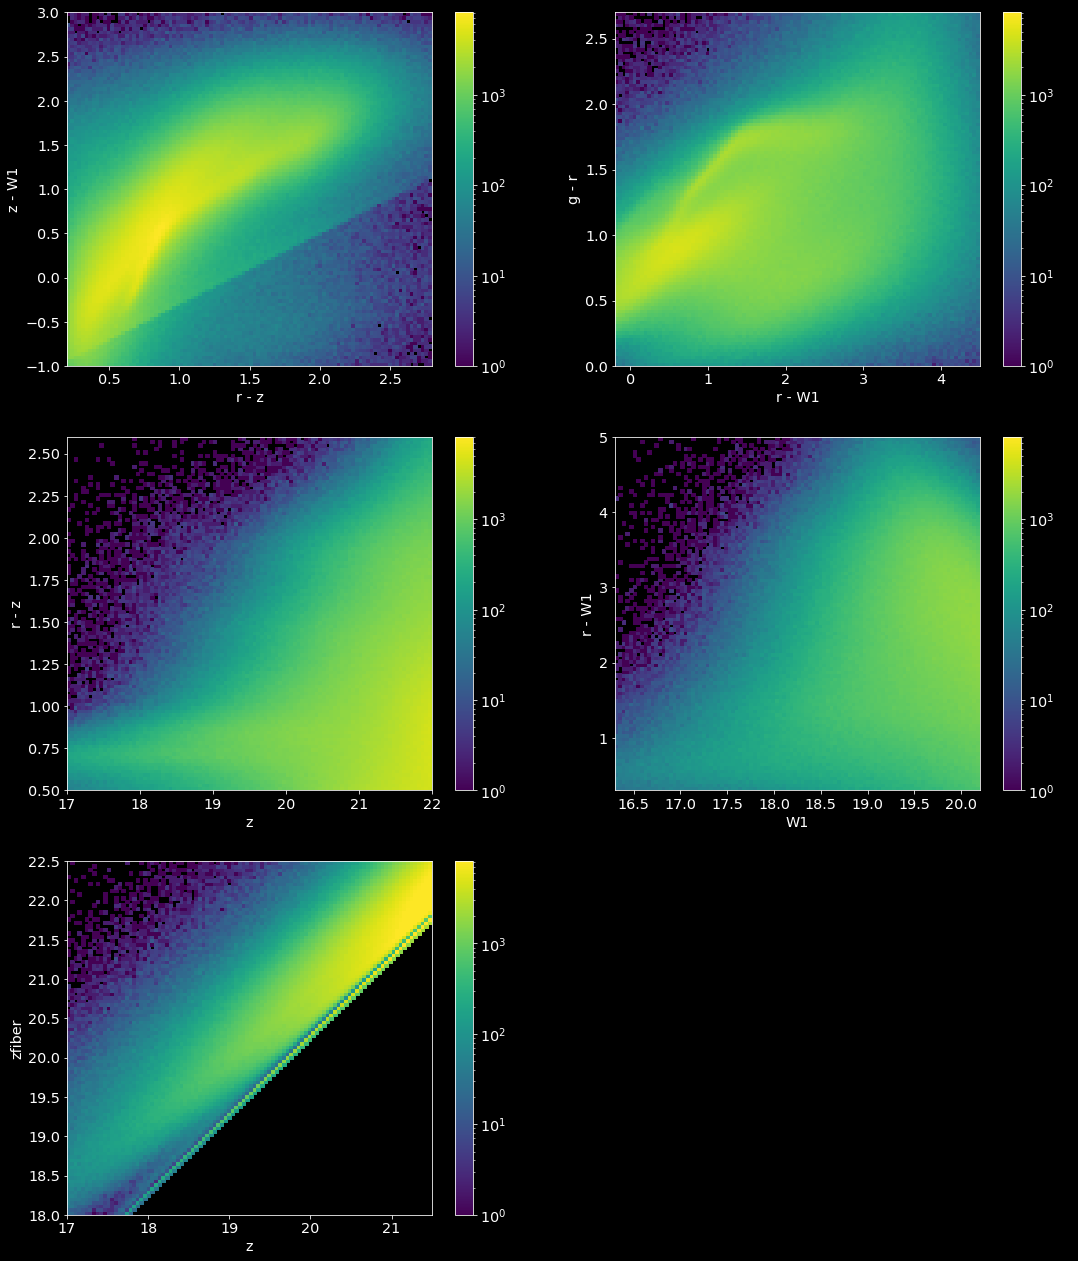

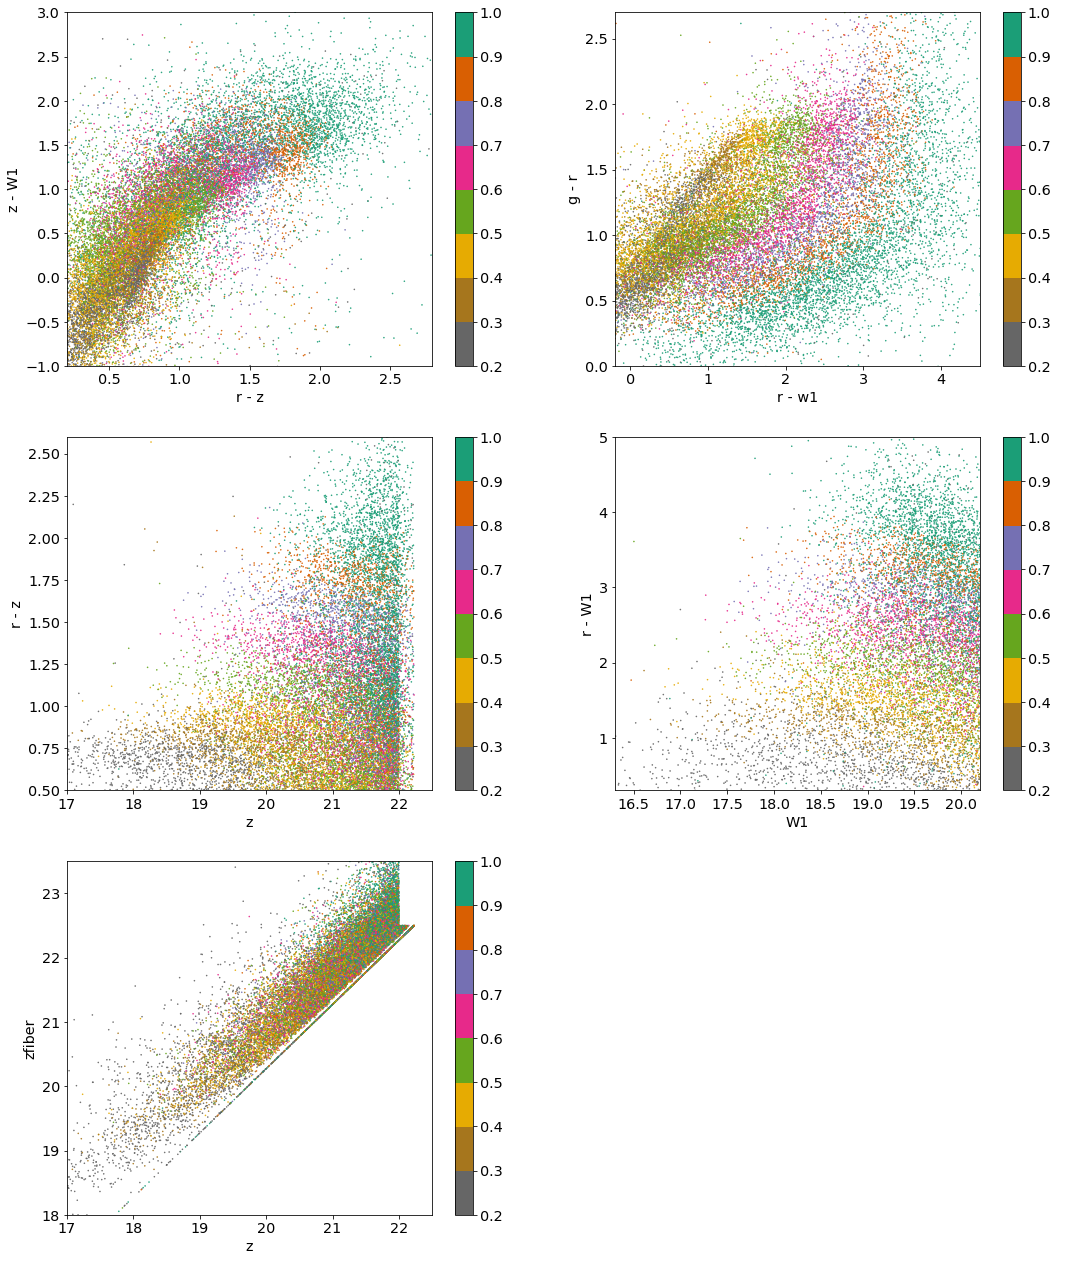

In [15]:
# Plot the color-magnitude distributions of the full catalog
lrg_plot.density_plot_3x2_new(cat)

idx = np.random.choice(len(cat), size=25000, replace=False)
lrg_plot.color_plot_3x2_new(cat, idx=idx)

----------
## Nominal selection

In [16]:
z2 = 16.83
print('{:.2f}  {:.2f}'.format(z2, z2/1.22))

lrg_mask = zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                     # faint limit

mask_red = (gmag - w1mag > 2.6) & (gmag - rmag > 1.4) # low-z cut
mask_red |= (rmag-w1mag) > 1.8                        # ignore low-z cut for faint objects
lrg_mask &= mask_red

lrg_mask &= rmag - zmag > (zmag - z2) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - z2/1.22) * 0.19  # low-z sliding optical cut

print_summary(lrg_mask)

16.83  13.80
target density: 599.0 per sq deg


In [17]:
# Fill in the numbers

lrg_mask = zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

mask_red = (gmag - w1mag > 2.6) & (gmag - rmag > 1.4) # low-z cut
mask_red |= (rmag-w1mag) > 1.8                   # ignore low-z cut for faint objects
lrg_mask &= mask_red

lrg_mask &= rmag - zmag > (zmag - 16.83) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.80) * 0.19       # low-z sliding optical cut

print_summary(lrg_mask)
density0 = np.sum(lrg_mask)/area_clean*downsample_factor

target density: 599.8 per sq deg


In [18]:
t = Table()
t['type'], t['counts'] = np.unique(cat['TYPE'][lrg_mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(lrg_mask)*100
t['frac (%)'].format = '%.1f'
t.sort('counts')
t

type,counts,frac (%)
str4,int64,float64
PSF,2316,1.0
EXP,11608,5.2
SER,34276,15.2
REX,53082,23.6
DEV,124100,55.1


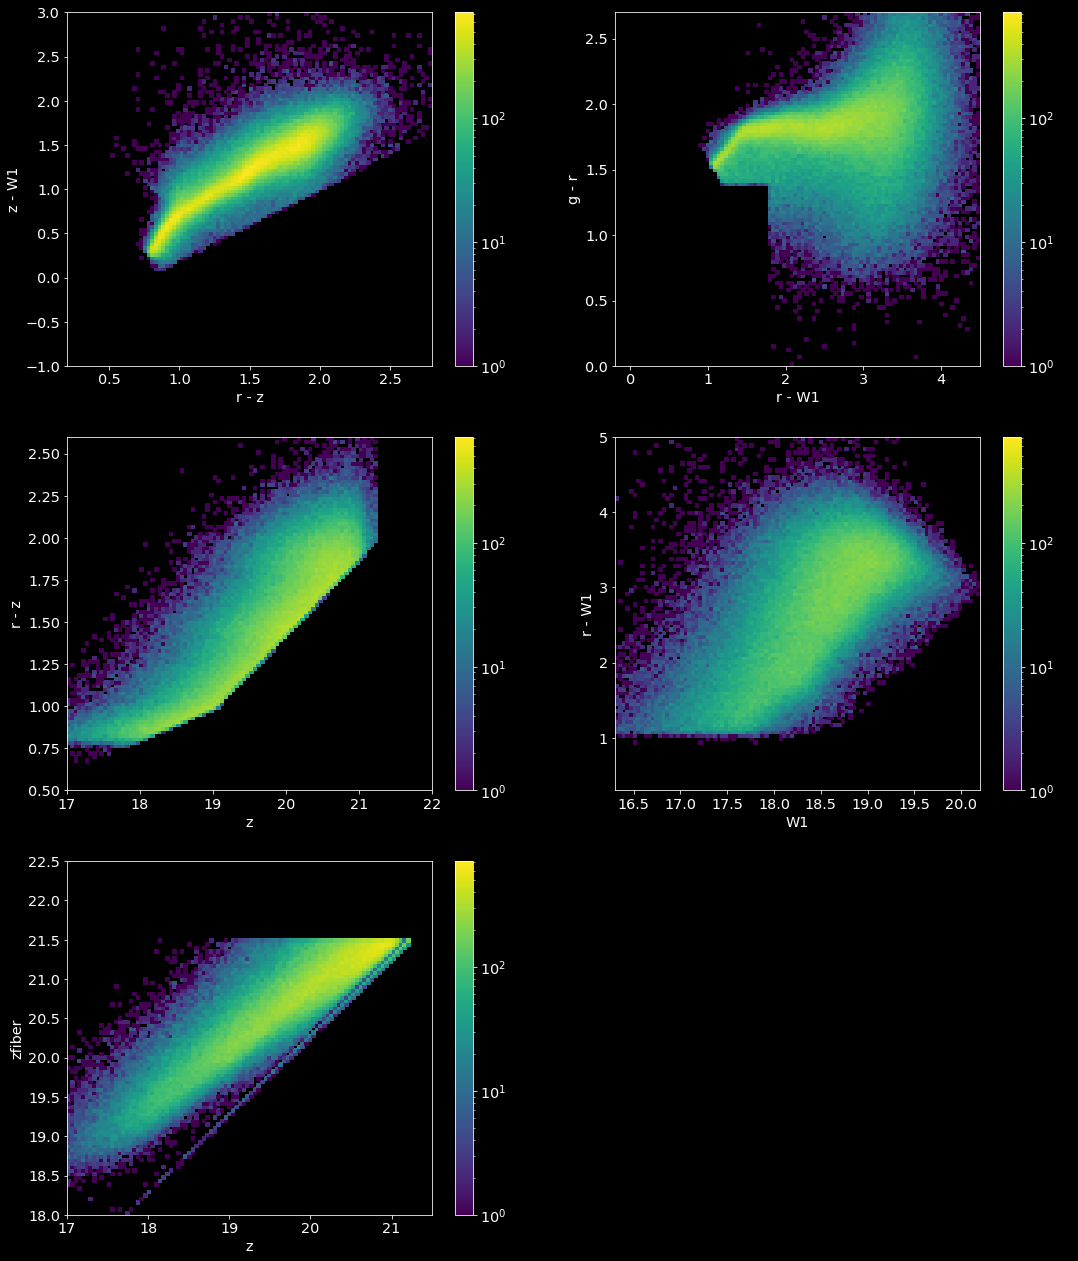

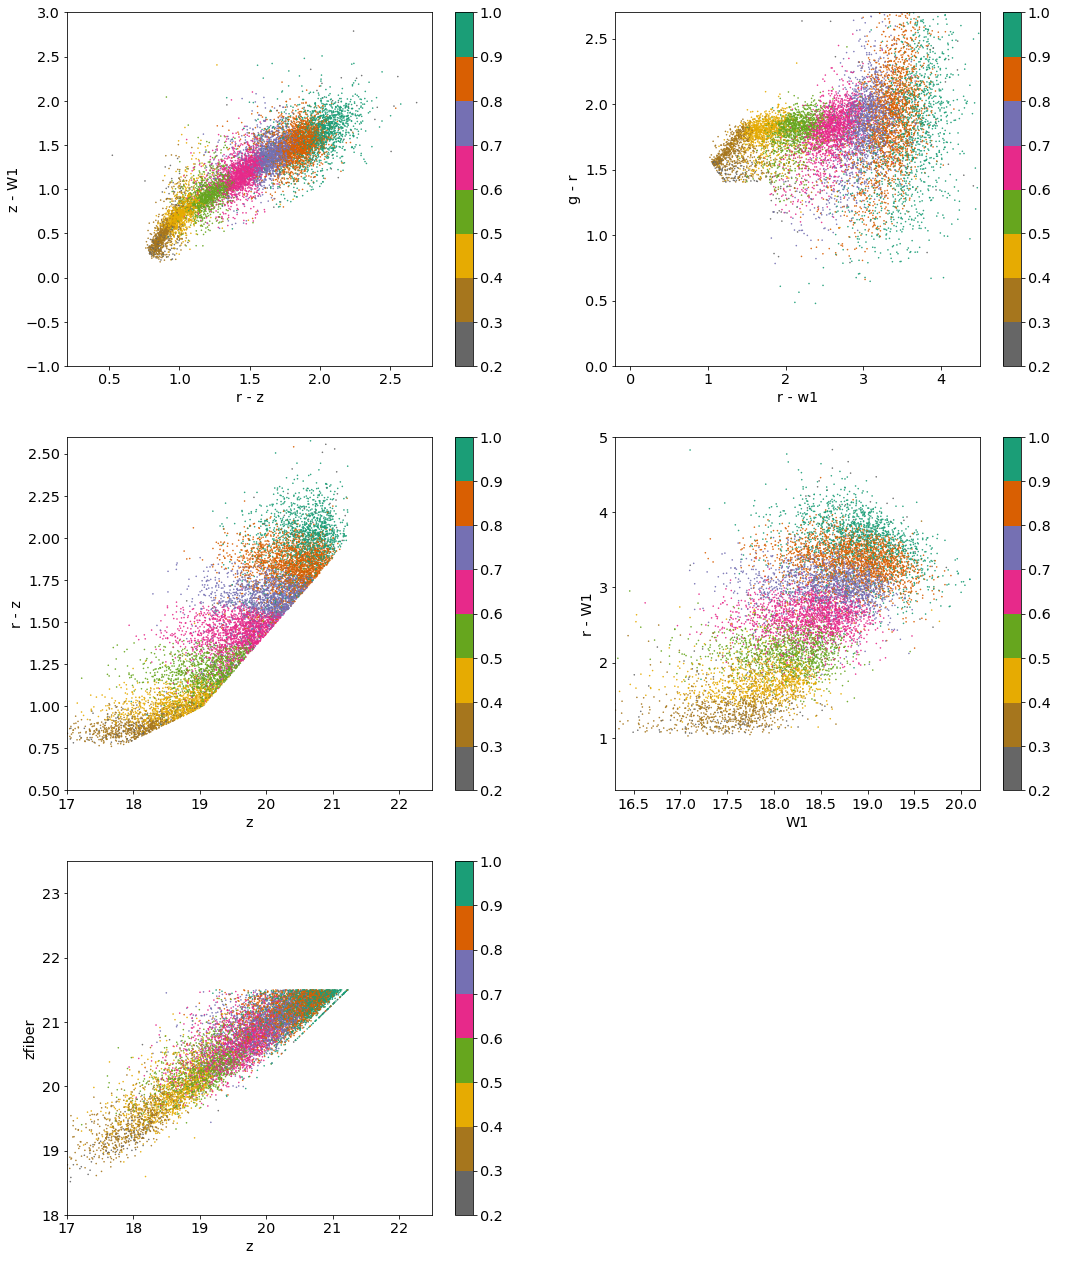

In [19]:
lrg_plot.density_plot_3x2_new(cat[lrg_mask])

idx = np.random.choice(np.where(lrg_mask)[0], size=10000, replace=False)
lrg_plot.color_plot_3x2_new(cat, idx=idx)

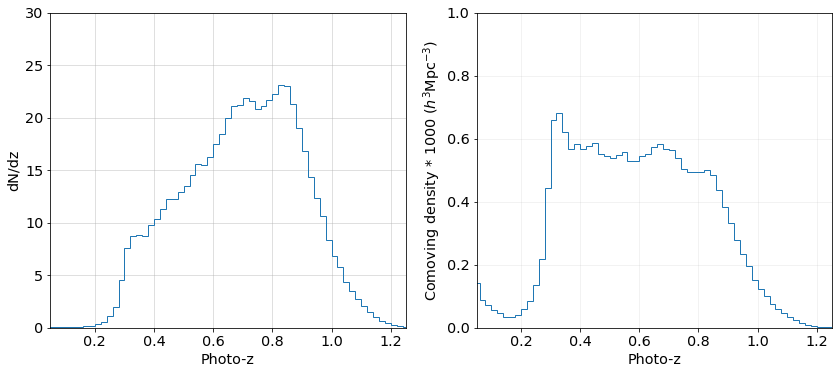

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(0.04, 1.44, 0.02)
axes[0].hist(z_phot_perturb[lrg_mask], bins=bins,
             weights=np.ones(int(np.sum(lrg_mask)))/area_clean*downsample_factor, histtype='step')
axes[0].set_xlabel('Photo-z')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(0.05, 1.25)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(z_phot_perturb[lrg_mask], area=area_clean/downsample_factor, zmin=0.04, zmax=1.44, dz=0.02, axis=[0.05, 1.25, 0, 1.])

In [21]:
mask = z_phot_perturb[lrg_mask]<0.3
print('fraction of z<0.3 objects: {:.2f}%'.format(np.sum(mask)/np.sum(lrg_mask)*100))

fraction of z<0.3 objects: 2.46%


------
## Full SV selection

In [22]:
p1, p2, p3, p4  = 23.18, 1.3, 2.5, 4.48
intercept, slope = -0.37, 0.45

lrg_mask = zmag - w1mag > 0.8 * (rmag-zmag) - 0.8  # non-stellar cut
lrg_mask &= ((zmag < 20.5) | (zfibermag < 21.9))   # faint limit

mask_red = (gmag - w1mag > 2.5) & (gmag - rmag > 1.3) # low-z cut
mask_red |= (rmag-w1mag) > 1.7                   # ignore low-z cut for faint objects
lrg_mask &= mask_red

# straight cut for low-z:
lrg_mask_lowz = zmag < 20.2
lrg_mask_lowz &= rmag - zmag > (zmag - 16.83 + intercept) * slope
lrg_mask_lowz &= rmag - zmag > (zmag - 13.80 + intercept) * 0.19
# curved sliding cut for high-z:
lrg_mask_highz = zmag >= 20.2
lrg_mask_highz &= (((zmag - p1) / p2)**2 + (rmag - zmag + p3)**2 > p4**2)

lrg_mask &= (lrg_mask_lowz | lrg_mask_highz)

# Check the r-z colors at the point of connection
print((20.2 - 16.83 + intercept) * slope)
mask = zmag >= 20.2
mask &= rmag-zmag>0 # remove outliers
print(np.min((rmag-zmag)[mask & lrg_mask]))
print((20.2 - 16.83 + intercept) * slope - np.min((rmag-zmag)[mask & lrg_mask]))

print_summary(lrg_mask)
lrg_mask1 = lrg_mask.copy()

1.3500000000000005
1.3510933
-0.001093292236327592
target density: 1467.8 per sq deg


20.238623862386238


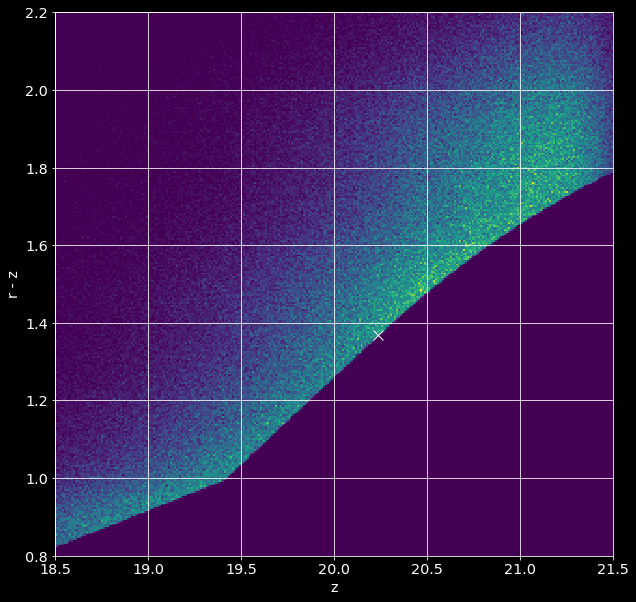

In [23]:
# Plot the closest point on sliding cut to the ellipse
xslide = np.linspace(18, 22, 10000)
yslide = (xslide - 16.83 + intercept) * slope
curve_val = ((xslide - p1) / p2)**2 + (yslide + p3)**2
xtouch, ytouch = xslide[np.argmin(curve_val)], yslide[np.argmin(curve_val)]
print(xtouch)

density_optical_fine(lrg_mask, lognorm=False, show=False)
plt.plot(xtouch, ytouch, 'wx', markersize=10)
# plt.axis([10, 25, 0, 5])

In [24]:
# Fill in the numbers
lrg_mask = zmag - w1mag > 0.8 * (rmag-zmag) - 0.8 # non-stellar cut
lrg_mask &= ((zmag < 20.5) | (zfibermag < 21.9))  # faint limit

mask_red = (gmag - w1mag > 2.5) & (gmag - rmag > 1.3) # low-z cut
mask_red |= (rmag-w1mag) > 1.7                   # ignore low-z cut for faint objects
lrg_mask &= mask_red

# straight cut for low-z:
lrg_mask_lowz = zmag < 20.2
lrg_mask_lowz &= rmag - zmag > (zmag - 17.20) * 0.45
lrg_mask_lowz &= rmag - zmag > (zmag - 14.17) * 0.19
# curved sliding cut for high-z:
lrg_mask_highz = zmag >= 20.2
lrg_mask_highz &= (((zmag - 23.18) / 1.3)**2 + (rmag - zmag + 2.5)**2 > 4.48**2)

lrg_mask &= (lrg_mask_lowz | lrg_mask_highz)

############################################
# Check the r-z colors at the point of connection
print((20.2 - 16.83 - 0.37) * 0.45)
mask = zmag >= 20.2
print(np.min((rmag-zmag)[mask & lrg_mask]))
print((20.2 - 16.83 - 0.37) * 0.45 - np.min((rmag-zmag)[mask & lrg_mask]))

print_summary(lrg_mask)
print(np.all(lrg_mask==lrg_mask1))

1.3500000000000005
1.3510933
-0.001093292236327592
target density: 1467.8 per sq deg
True


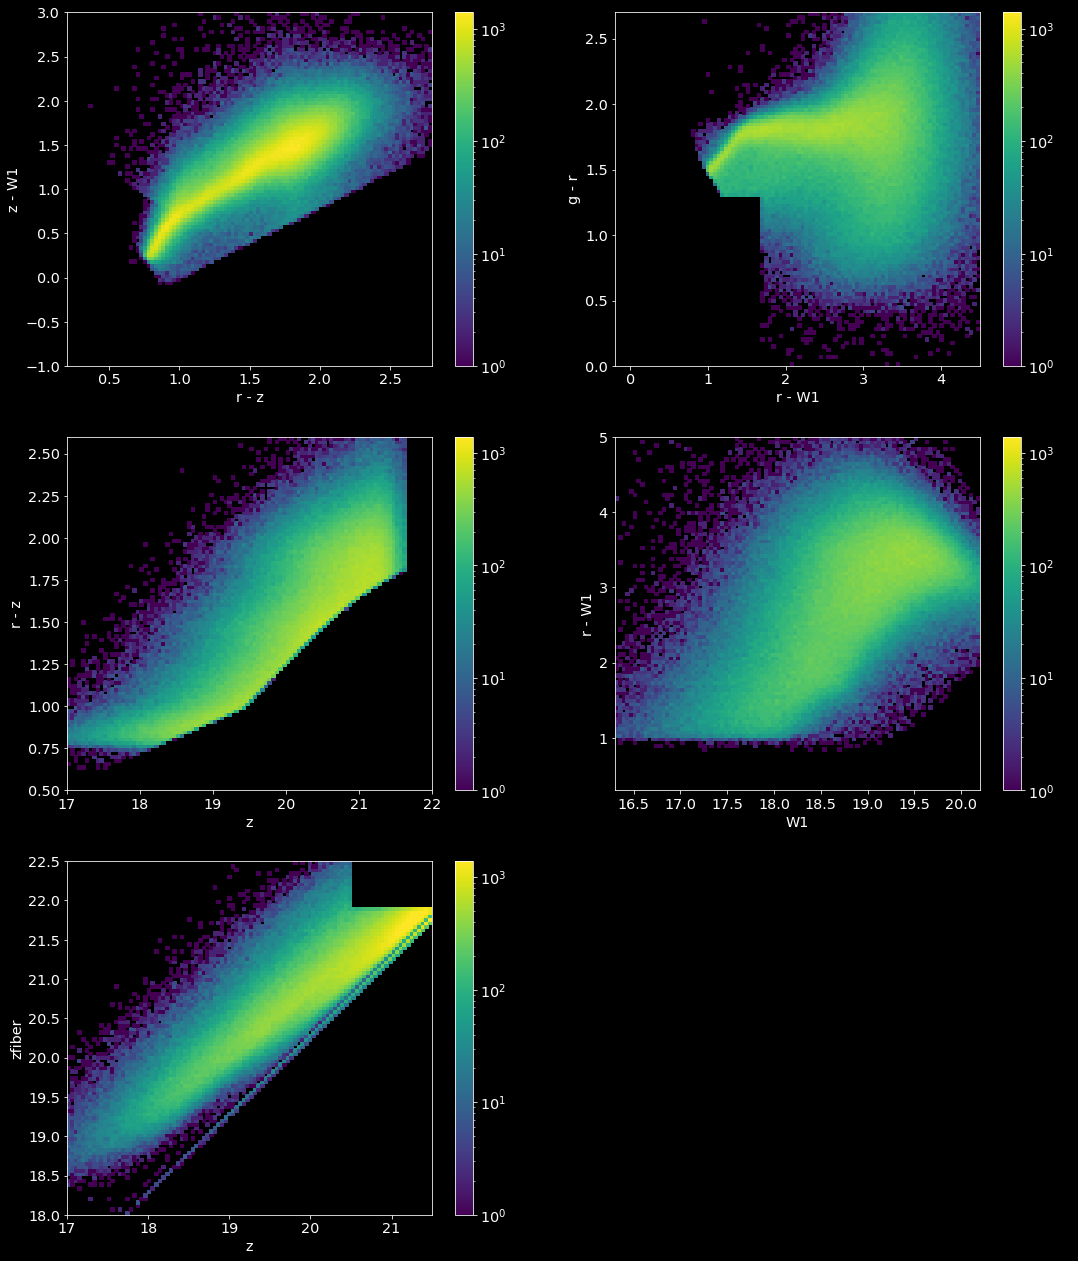

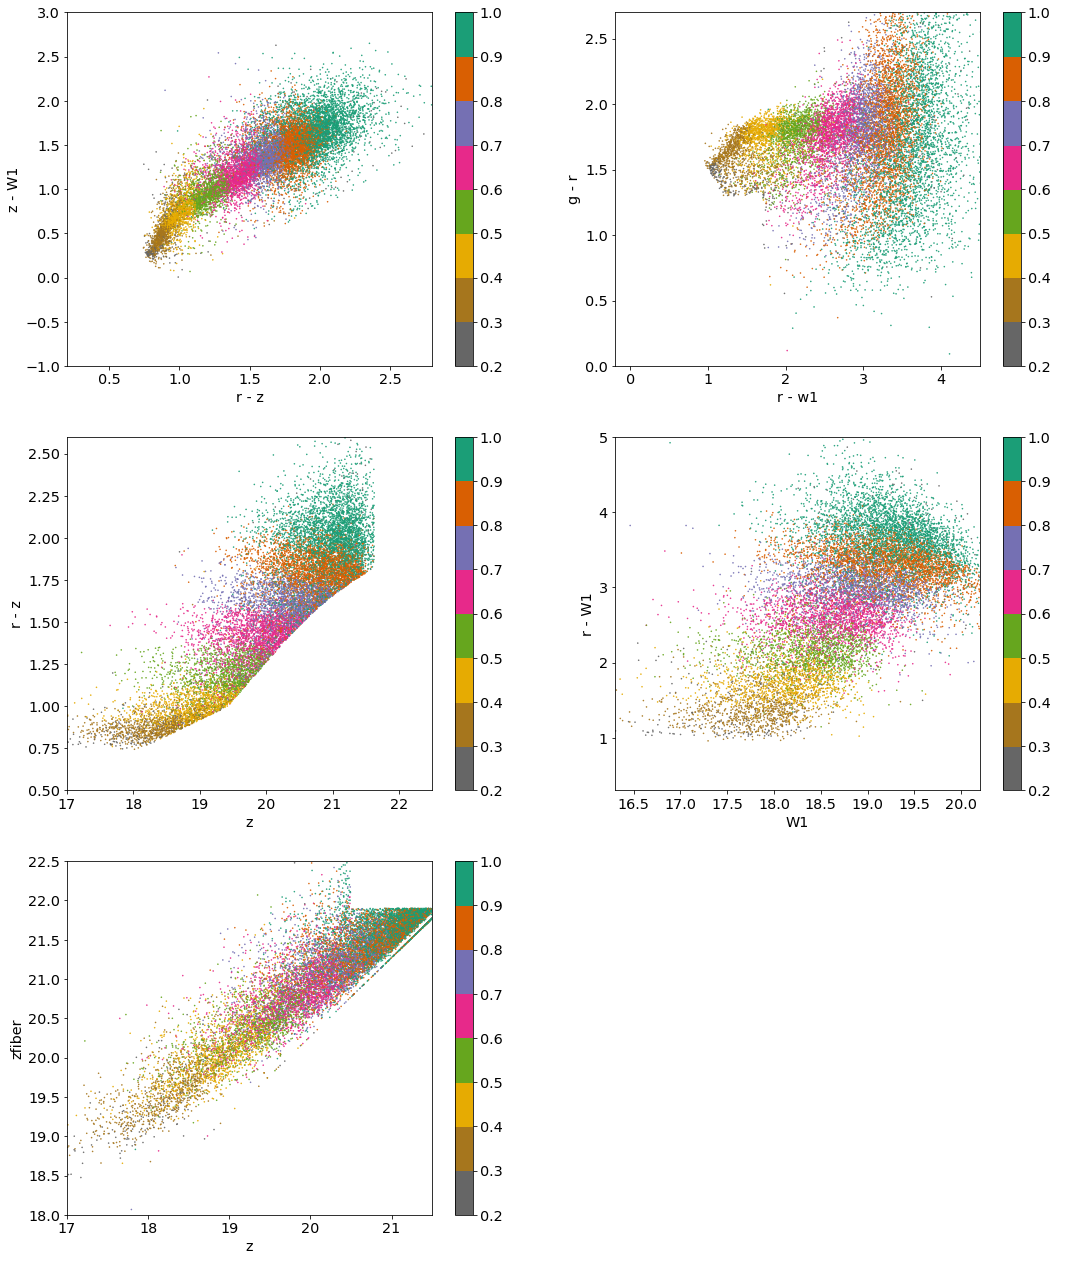

In [25]:
lrg_plot.density_plot_3x2_new(cat[lrg_mask])

idx = np.random.choice(np.where(lrg_mask)[0], size=15000, replace=False)
lrg_plot.color_plot_3x2_new(cat, idx=idx)

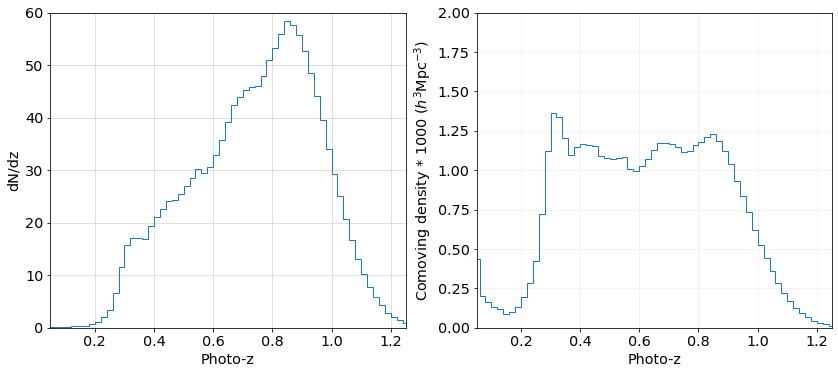

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(0.04, 1.44, 0.02)
axes[0].hist(z_phot_perturb[lrg_mask], bins=bins,
             weights=np.ones(int(np.sum(lrg_mask)))/area_clean*downsample_factor, histtype='step')
axes[0].set_xlabel('Photo-z')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(0.05, 1.25)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
axes[0].set_ylim(top=60)
axes[1] = lrg_plot.plot_comoving_density(z_phot_perturb[lrg_mask], area=area_clean/downsample_factor, zmin=0.04, zmax=1.44, dz=0.02, axis=[0.05, 1.25, 0, 2.])

In [27]:
mask = z_phot_perturb[lrg_mask]<0.3
print('fraction of z<0.3 objects: {:.2f}%'.format(np.sum(mask)/np.sum(lrg_mask)*100))

fraction of z<0.3 objects: 3.04%


__Find the closest point in the curved sliding cut extension__

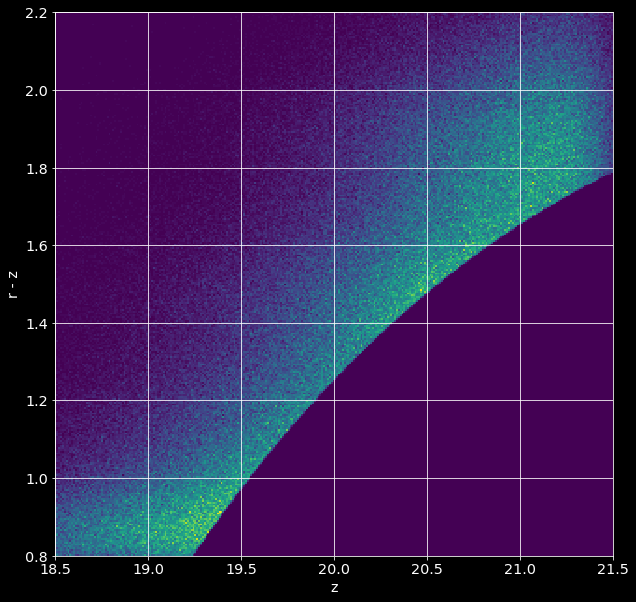

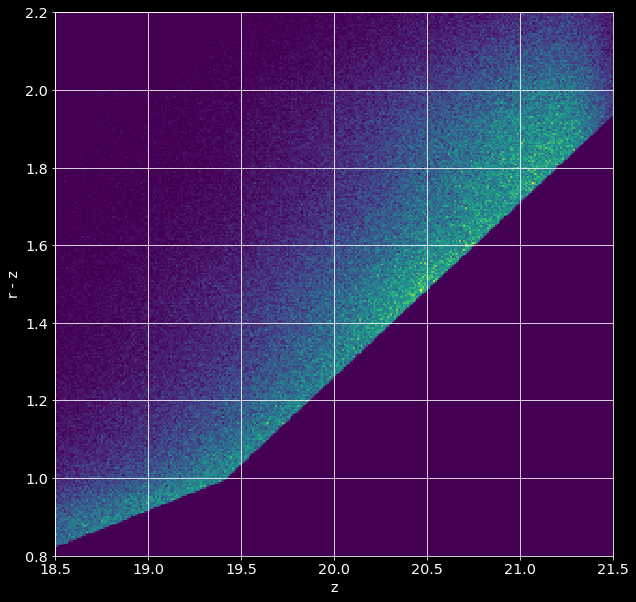

In [28]:
lrg_mask = zmag - w1mag > 0.8 * (rmag-zmag) - 0.8  # non-stellar cut
lrg_mask &= ((zmag < 20.5) | (zfibermag < 21.9))   # faint limit

mask_red = (gmag - w1mag > 2.5) & (gmag - rmag > 1.3) # low-z cut
mask_red |= (rmag-w1mag) > 1.7                   # ignore low-z cut for faint objects
lrg_mask &= mask_red

lrg_mask &= (((zmag - 23.18) / 1.3)**2 + (rmag - zmag + 2.5)**2 > 4.48**2)

density_optical_fine(lrg_mask, lognorm=False)

##################################################

lrg_mask = zmag - w1mag > 0.8 * (rmag-zmag) - 0.8  # non-stellar cut
lrg_mask &= ((zmag < 20.5) | (zfibermag < 21.9))   # faint limit

mask_red = (gmag - w1mag > 2.5) & (gmag - rmag > 1.3) # low-z cut
mask_red |= (rmag-w1mag) > 1.7                   # ignore low-z cut for faint objects
lrg_mask &= mask_red

lrg_mask &= rmag - zmag > (zmag - 16.83 - 0.37) * 0.45
lrg_mask &= rmag - zmag > (zmag - 13.80 - 0.37) * 0.19

density_optical_fine(lrg_mask, lognorm=False)

The curved extension is 0.37 magnitude fainter than the nominal single-exposure sliding cut in zmag at the closes point.

--------
## Zero-point sensitivity for the nominal selection

In [29]:
z2 = 16.83
for band in ['gmag', 'rmag', 'zmag', 'w1mag']:

    cat1 = cat.copy()
    cat1[band] = cat1[band] - 0.005
    if band=='zmag':
        cat1['zfibermag'] = cat1['zfibermag'] - 0.005
    lrg_mask = cat1['zmag'] - cat1['w1mag'] > 0.8 * (cat1['rmag']-cat1['zmag']) - 0.6  # non-stellar cut
    lrg_mask &= (cat1['zfibermag'] < 21.5)                   # faint limit
    mask_red = (cat1['gmag'] - cat1['w1mag'] > 2.6) & (cat1['gmag'] - cat1['rmag'] > 1.4) # low-z cut
    mask_red |= (cat1['rmag']-cat1['w1mag']) > 1.8                   # ignore low-z cut for faint objects
    lrg_mask &= mask_red
    lrg_mask &= cat1['rmag'] - cat1['zmag'] > (cat1['zmag'] - z2) * 0.45       # sliding optical cut
    lrg_mask &= cat1['rmag'] - cat1['zmag'] > (cat1['zmag'] - z2/1.22) * 0.19       # low-z sliding optical cut
    density1 = np.sum(lrg_mask)/area_clean*downsample_factor

    cat1 = cat.copy()
    cat1[band] = cat1[band] + 0.005
    if band=='zmag':
        cat1['zfibermag'] = cat1['zfibermag'] + 0.005
    lrg_mask = cat1['zmag'] - cat1['w1mag'] > 0.8 * (cat1['rmag']-cat1['zmag']) - 0.6  # non-stellar cut
    lrg_mask &= (cat1['zfibermag'] < 21.5)                   # faint limit
    mask_red = (cat1['gmag'] - cat1['w1mag'] > 2.6) & (cat1['gmag'] - cat1['rmag'] > 1.4) # low-z cut
    mask_red |= (cat1['rmag']-cat1['w1mag']) > 1.8                   # ignore low-z cut for faint objects
    lrg_mask &= mask_red
    lrg_mask &= cat1['rmag'] - cat1['zmag'] > (cat1['zmag'] - z2) * 0.45       # sliding optical cut
    lrg_mask &= cat1['rmag'] - cat1['zmag'] > (cat1['zmag'] - z2/1.22) * 0.19       # low-z sliding optical cut
    density2 = np.sum(lrg_mask)/area_clean*downsample_factor

    # print(density1, density2)
    fractional_diff = (density2-density1)/density0*100
    sign = '+' if fractional_diff>=0 else '-'
    
    print('Net change of +0.01 in {}: {}{:.2}% change in target density'.format(band, sign, np.abs(fractional_diff)))

Net change of +0.01 in gmag: +0.19% change in target density
Net change of +0.01 in rmag: +3.7% change in target density
Net change of +0.01 in zmag: -6.1% change in target density
Net change of +0.01 in w1mag: -0.16% change in target density
